# Importance Sampling

In this notebook, I implement the importance sampling method for option pricing.
The content of this notebook is based on Chapter 4 of the book "Monte Carlo Methods in Financial Engineering" by Paul Glasserman.

If the barrier of an up-and-in option is much higher than the initial value, it is unlikely that the option will have a non-zero payoff. To deal with this, we use the Girsanov theorem to change (tilt) the Wiener process so that knock-in events happen more often.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

# 1. Parameters

In [2]:
time_step = 0.01
terminal_time = 1
time_grid = np.arange(0, terminal_time + time_step, time_step)
num_steps = len(time_grid)

num_total_samples = 10000

initial_stock_price = 100
riskless = 0.03
strike_price = 105
barrier = 150

# "sigma" is a volatility term of GBM
sigma = 0.2

# "alpha" is a significance level for the confidence interval.
alpha = 0.05

# "theta" is the exponential tilting parameter
theta = 2

# 2. Construction of Wiener processes

Let $W$ be a Wiener process under the probability measure $P$.
For a constant $\theta$, we define the process $\tilde{W}(t) = W(t) + \theta t$.
Then, by Girsanov's theorem, there exists a new probability measure $P_{\theta}$ under which $\tilde{W}$ becomes a Wiener process, and
$$ \frac{dP}{dP_{\theta}} = \exp \left(- \theta W(T) - \frac{1}{2} \theta^2 T \right)$$

In [3]:
W = np.zeros((num_total_samples, num_steps))
for i in range(num_total_samples):
    for j in range(num_steps-1):
        Z = np.random.normal(loc=0,scale=1)
        W[i][j+1] = W[i][j] + np.sqrt(time_grid[j+1] - time_grid[j]) * Z
W_tilde = W + theta * time_grid

likelihood_ratio = np.zeros(num_total_samples)
for i in range(num_total_samples):
    likelihood_ratio[i] = np.exp(- theta * W[i][num_steps-1] - 0.5 * theta**2 * terminal_time)

print(np.mean(likelihood_ratio))

1.0357229613968728


# 3. Computation of stock prices

We consider the case that the underlying stock price follows a Geometric Brownian Motion (GBM):
$$ \frac{dS(t)}{S(t)} = r dt + \sigma d \tilde{W}(t).$$
Therefore, we have the explicit form
$$ S(t) = S(0) \exp \left \{ \left (r - \frac{1}{2} \sigma^2 \right )t + \sigma \tilde{W}(t) \right \}$$

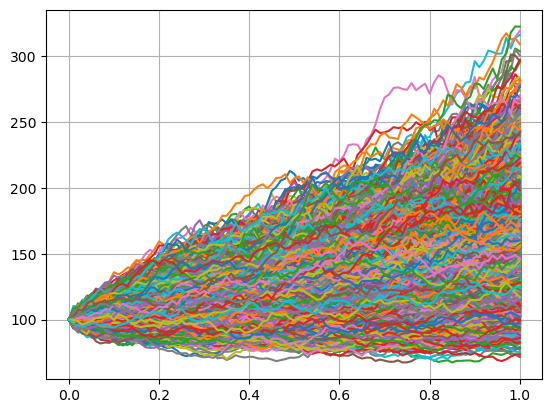

In [4]:
stock_price = np.zeros((num_total_samples, num_steps))
for i in range(num_total_samples):
    stock_price[i][0] = initial_stock_price
    for j in range(1,num_steps):
        stock_price[i][j] = initial_stock_price * np.exp((riskless - 1/2 * sigma**2) * time_grid[j] + sigma * W_tilde[i][j])

for i in range(num_total_samples):
    plt.plot(time_grid, stock_price[i])
plt.grid(True)
plt.show()

# 4. Calculation of option payoff

The payoff of up-and-in call option is
$$ max(S(T) - K,0) 1_{\{max_{1 \le i \le m} S(t_i) > b \}}$$

In [5]:
up_and_in_call_value = np.zeros(num_total_samples)
for i in range(num_total_samples):
    if np.max(stock_price[i]) > barrier:
        up_and_in_call_value[i] = np.exp(-riskless * terminal_time) * max(stock_price[i][num_steps-1] - strike_price, 0)

print(f"The number of \n\
      - Knocked-in paths: {np.count_nonzero(up_and_in_call_value)}, and \n\
      - Non-knocked-in paths: {num_total_samples - np.count_nonzero(up_and_in_call_value)}, and \n\
      - Total paths: {num_total_samples} \n")

The number of 
      - Knocked-in paths: 5790, and 
      - Non-knocked-in paths: 4210, and 
      - Total paths: 10000 



# 5. Estimation of a confidence interval

In [6]:
Y = up_and_in_call_value * likelihood_ratio
estimated_price = np.mean(Y)
std = np.std(Y, ddof=1)

z = norm.ppf(1 - alpha/2)
conf_int_lower = estimated_price - z * std/np.sqrt(num_total_samples)
conf_int_upper = estimated_price + z * std/np.sqrt(num_total_samples)

print(f"The estimated value is {estimated_price:.3f}, and \n\
{(1-alpha)*100}% confidence interval is ({conf_int_lower:.3f},{conf_int_upper:.3f}). \n\
The length of this interval  is {conf_int_upper - conf_int_lower:.4f}")

The estimated value is 1.945, and 
95.0% confidence interval is (1.894,1.996). 
The length of this interval  is 0.1020


# 6. Comparison with plain Monte Carlo estimator

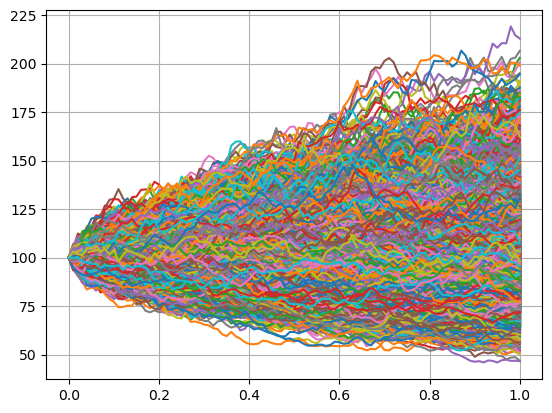

The number of 
      - Knocked-in paths: 417, and 
      - Non-knocked-in paths: 9583, and 
      - Total paths: 10000 

The estimated value is 1.926, and 
95.0% confidence interval is (1.735,2.118). 
The length of this interval  is 0.3821


In [7]:
stock_price = np.zeros((num_total_samples, num_steps))
W = np.zeros((num_total_samples, num_steps))
for i in range(num_total_samples):
    for j in range(num_steps-1):
        Z = np.random.normal(loc=0,scale=1)
        W[i][j+1] = W[i][j] + np.sqrt(time_grid[j+1] - time_grid[j]) * Z

for i in range(num_total_samples):
    stock_price[i][0] = initial_stock_price
    for j in range(1,num_steps):
        stock_price[i][j] = initial_stock_price * np.exp((riskless - 1/2 * sigma**2) * time_grid[j] + sigma * W[i][j])


for i in range(num_total_samples):
    plt.plot(time_grid, stock_price[i])
plt.grid(True)
plt.show()


up_and_in_call_value = np.zeros(num_total_samples)
for i in range(num_total_samples):
    if np.max(stock_price[i]) > barrier:
        up_and_in_call_value[i] = np.exp(-riskless * terminal_time) * max(stock_price[i][num_steps-1] - strike_price, 0)

print(f"The number of \n\
      - Knocked-in paths: {np.count_nonzero(up_and_in_call_value)}, and \n\
      - Non-knocked-in paths: {num_total_samples - np.count_nonzero(up_and_in_call_value)}, and \n\
      - Total paths: {num_total_samples} \n")


estimated_price = np.mean(up_and_in_call_value)
std = np.std(up_and_in_call_value, ddof=1)

z = norm.ppf(1 - alpha/2)
conf_int_lower = estimated_price - z * std/np.sqrt(num_total_samples)
conf_int_upper = estimated_price + z * std/np.sqrt(num_total_samples)

print(f"The estimated value is {estimated_price:.3f}, and \n\
{(1-alpha)*100}% confidence interval is ({conf_int_lower:.3f},{conf_int_upper:.3f}). \n\
The length of this interval  is {conf_int_upper - conf_int_lower:.4f}")

# Reference

1. Glasserman, P. (2003) *Monte Carlo Methods in Financial Engineering*. Springer, New York.